# X-Phi Journals

## Set Up Notebook

In [1]:
##########
# IMPORT #
##########

# Future imports
from __future__ import annotations

# Standard library imports
import re
from pathlib import Path

# Third-party library imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


#################
# CONFIGURATION #
#################

# Define publication periods
PERIODS = [
    "2001–2005",
    "2006–2010",
    "2011–2015",
    "2016–2020",
    "2021–2025"
]

# Standardize journal names
JOURNAL_MAP = {
    "Journal of Experimental Psychology General": "Journal of Experimental Psychology: General",
    "Journal of Experimental Psychology. General": "Journal of Experimental Psychology: General",
    "Mind and Language": "Mind & Language",
    "Monist": "The Monist",
    "Nous": "Noûs",
    "Philosophy & Phenomenological Research": "Philosophy and Phenomenological Research",
    "PLOS One": "PLOS ONE",
    "PLoS ONE": "PLOS ONE",
    "Plos One": "PLOS ONE",
    "Review of Philosophy & Psychology": "Review of Philosophy and Psychology",
    "Stanford Encyclopaedia of Philosophy": "Stanford Encyclopedia of Philosophy",
    "The Journal of Aesthetics and Art Criticism": "Journal of Aesthetics and Art Criticism",
}

# Standardize publisher names
PUBLISHER_MAP = {
    "OUP USA": "Oxford University Press",
}

# Define keywords indicating a journal
JOURNAL_KEYWORDS = [
    "analysis",
    "cognition",
    "cognitive science",
    "erkenntnis",
    "ethics",
    "inquiry",
    "issn",
    "journal",
    "language",
    "mind",
    "monist",
    "no.",
    "nous",
    "noûs",
    "philosophia",
    "quarterly",
    "review",
    "studies",
    "synthese",
    "theoria",
    "vol."
]

# Define keywords indicating another source
NON_JOURNAL_KEYWORDS = [
    "book",
    "companion",
    "dissertation",
    "edited",
    "eds.",
    "ed.",
    "edition",
    "encyclopedia",
    "handbook",
    "isbn",
    "publisher",
    "press",
    "proceedings",
    "routledge",
    "springer"
]

## Define Helper Functions

In [2]:
# Define function to strip excessive whitespaces
def compact_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", str(text).strip())

# Define function to create a score for assessing likelihood of being from a journal
def candidate_source_score(candidate: str) -> int:
    c = candidate.strip()
    cl = c.lower()
    score = 0
    
    # Add one point if volume-issue pattern is detected
    if re.search(r"\b\d{1,4}\s*(?:\([^)]*\))?\s*[: ,]\s*(?:(?:p|pp|s)\.?\s*)?\d+", c, re.IGNORECASE):
        score += 1
    
    # Add one point per match with JOURNAL_KEYWORDS
    score += sum(1 for k in JOURNAL_KEYWORDS if re.search(rf"\b{re.escape(k)}(?!\w)", cl))
    
    # Subtract one point per match with NON_JOURNAL_KEYWORDS
    score -= sum(1 for k in NON_JOURNAL_KEYWORDS if re.search(rf"\b{re.escape(k)}", cl))
    
    return score

# Define function to find spot where title ends and source begins
def split_title_source(rest: str) -> tuple[str, str, str, int]:
    
    # Remove leading dots or spaces
    rest = compact_spaces(re.sub(r"^\.\s*", "", rest))
    
    # Find full stops, commas, exclamation marks, and question marks as indicators for the end of a title
    boundaries = list(re.finditer(r"(?<=[.,!?])\s+", rest))
    
    # Leave source empty when no indicator is found
    if not boundaries:
        return rest.strip(" ."), "", "No boundary found", 0
    
    # Check boundaries to see which one is likely to separate title and source
    best = None
    
    # Cut text into two snippets
    for m in boundaries:
        title = rest[:m.start()].strip()   # Everything before indicator is potential title
        source = rest[m.end():].strip()    # Everything after indicator is potential source
        
        # Apply candidate_source_score
        score = candidate_source_score(source)
        
        # Set minimum score for a snippet to count as following a high-confidence split
        if score >= 1:
            
            # Save split point that precedes the highest scoring snippet
            if best is None or score > best[0]:
                best = (score, m.start(), title, source)
    
    # Return high-confidence split if found
    if best:
        return best[2].strip(" ."), best[3].strip(), "", best[0]
    
    # Return low-confidence split at last punctuation mark if no high-confidence split is found
    m = boundaries[-1]
    return rest[:m.start()].strip(" ."), rest[m.end():].strip(), "Low-confidence split", 0

# Define function to strip volume, issue, and page numbers
def strip_volume_issue_pages(source: str) -> str:
    s = compact_spaces(source).strip(" .,:;")
    s = re.sub(r"\s+\d{1,4}\s*\([^)]*\)\s*:\s*[\w–\-\—].*$", "", s)
    s = re.sub(r"\s+\d{1,4}\s*:\s*[\w–\-\—].*$", "", s)
    s = re.sub(r"\s+\d{1,4}\s*\([^)]*\)\s*$", "", s)
    s = re.sub(r"\s+\d{1,4}\s*$", "", s)
    return s.strip(" .,:;")

# Define function to separate journals from other publications
def classify_source_type(standardized: str, score: int) -> str:
    
    # Normalize for case-insensitive comparison
    s = standardized.lower()
    
    # Check for matches with NON_JOURNAL_KEYWORDS
    if any(k in s for k in NON_JOURNAL_KEYWORDS):
        return "Other"
    
    # Check score
    if score >= 1:
        return "Likely journal"
    
    # Flag for review if no keywords matched and score is below 1
    return "Needs review"

# Define function to clean string, map standard names, and classify source
def standardize_source(source: str | None, score: int = 0) -> tuple[str, str]:
    
    # Returns "Unknown" if data is empty
    if not source: return "", "Unknown"
    
    # Collapse multiple spaces and strip leading or trailing dots or whitespace
    s = compact_spaces(source).strip(" .")
    
    # Check for matches with PUBLISHER_MAP
    for raw, std in PUBLISHER_MAP.items():
        if raw.lower() in s.lower():
            return std, "Other"
    
    # Apply strip_volume_issue_pages
    s = strip_volume_issue_pages(s)
    
    # Normalize journal names using JOURNAL_MAP
    s = JOURNAL_MAP.get(s, s)
    
    # Apply classify_source_type
    stype = classify_source_type(s, score)
    
    # Return standardized name and source type
    return s, stype

## Analyze Data

In [3]:
# Define function to parse entries into authors, year, title, and source
def parse_reference(ref: str) -> dict:
    
    # Locate publication year
    match = re.search(r"[\(\[]\b((?:19|20)\d{2})\b[\)\]]", ref)
    
    # Flag entry as invalid if no publication year is found
    if not match:
        return {
            "Authors": "Unknown",
            "Year":    0,
            "Source":  "",
            "Period":  None,
            "Score":   0
        }
    
    # Extract publication year
    year = match.group(1)
    
    # Split entry into authors and the rest
    parts = re.split(re.escape(match.group(0)), ref, maxsplit = 1)
    
    # Strip trailing or leading spaces and punctuation
    authors = parts[0].strip(" .")
    rest = parts[1].strip(" .") if len(parts) > 1 else ""
    
    # Apply split_title_source to the rest
    title, source, _, score = split_title_source(rest)
    
    # Assign time period
    year_int = int(year)
    period = next((p for p in PERIODS if int(p[:4]) <= year_int <= int(p[-4:])), None)
    
    # Return dictionary
    return {
        "Authors": authors,
        "Year":    year_int,
        "Title":   title,
        "Source":  source,
        "Period":  period,
        "Score":   score
    }

# Define function to read, parse, standardize, and aggregate entries
def run_analysis():
    
    # Check if file exists
    p = Path("x_phi_journals_philpapers.txt")
    if not p.exists(): return print("File is missing"), None
    
    # Read file line by line
    lines = [line.strip() for line in p.read_text(encoding = "utf-8").splitlines() if line.strip()]
    
    # Apply parse_reference
    df = pd.DataFrame([parse_reference(line) for line in lines])
    
    # Drop rows where year parsing failed
    df = df[df["Year"] > 0].copy()
    
    # Apply standardize_source
    std = df.apply(lambda r: standardize_source(r["Source"], r["Score"]), axis = 1)
    
    # Extract resulting tuple elements into their new DataFrame columns
    df["Standardized source"] = std.apply(lambda x: x[0])
    df["Source type"] = std.apply(lambda x: x[1])
    
    # Isolate entries that are likely to be from journals
    data = df[df["Source type"] == "Likely journal"].copy()
    
    # Drop entries where journal name is empty
    data = data[data["Standardized source"].str.strip().ne("")]
    
    # Stop if filtering did not leave any data
    if data.empty:
        print("No journals identified")
        return None, df
    
    # Create frequency matrix (rows = journals, columns = time periods, values = publication count)
    rank = pd.crosstab(data["Standardized source"], data["Period"])
    
    # Ensure all time periods exist as columns
    for p_col in PERIODS:
        if p_col not in rank.columns: rank[p_col] = 0
    
    # Reorder columns chronologically
    rank = rank[PERIODS]
    
    # Calculate total publications per journal
    rank["Total"] = rank.sum(axis = 1)
    
    # Sort DataFrame
    rank = rank.reset_index().sort_values(["Total"] + PERIODS[::-1], ascending = [False] * 6).reset_index(drop = True)
    
    # Insert ranking number as first column
    rank.insert(0, "Rank", range(1, len(rank) + 1))

    # Return rank and processed DataFrame
    return rank, df

# Run function to read, parse, standardize, and aggregate entries
rank_table, full_df = run_analysis()

# Output top ten journals
if rank_table is not None:
    display(rank_table.head(10))

# Output manual review queue
if full_df is not None:
    needs_review_all = full_df[full_df["Source type"] == "Needs review"]
    print(f"\nItems needing manual review: {len(needs_review_all)}")
    display(needs_review_all)

Period,Rank,Standardized source,2001–2005,2006–2010,2011–2015,2016–2020,2021–2025,Total
0,1,Philosophical Psychology,6,18,45,38,31,138
1,2,Synthese,5,0,17,43,39,104
2,3,Review of Philosophy and Psychology,0,18,29,24,27,98
3,4,Cognition,0,11,23,20,19,73
4,5,Mind & Language,2,25,19,20,6,72
5,6,Philosophical Studies,1,9,17,16,5,48
6,7,Cognitive Science,2,0,12,22,11,47
7,8,Journal of Business Ethics,8,13,4,9,1,35
8,9,Philosophy and Phenomenological Research,2,6,12,10,0,30
9,10,Journal of Cognition and Culture,0,15,9,3,2,29



Items needing manual review: 617


,Authors,Year,Title,Source,Period,Score,Standardized source,Source type
8,"Contesi, Filippo ; Terrone, Enrico ; Campdelac...",2024,Beauty Beyond the Subjective and Objective,Institute of Art and Ideas News,2021–2025,0,Institute of Art and Ideas News,Needs review
13,"Cova, Florian",2023,Experimental Philosophy of Aesthetics: Aesthet...,393-416,2021–2025,0,393-416,Needs review
17,"Weinberg, Jonathan",2018,Are aestheticians' intuitions sitting pretty? ...,London: Bloomsbury Academic,2016–2020,0,London: Bloomsbury Academic,Needs review
18,"Andow, James",2018,Aesthetic testimony and experimental philosoph...,London: Bloomsbury Academic,2016–2020,0,London: Bloomsbury Academic,Needs review
20,"Bonard, Constant ; Cova, Florian & Humbert-Dro...",2022,De gustibus est disputandum: An empirical inve...,77-108,2021–2025,0,77-108,Needs review
...,...,...,...,...,...,...,...,...
3403,"Betti, Arianna ; Reynaert, Martin & Van Den Be...",2017,@PhilosTEI: Building Corpora for Philosophers....,379-392,2016–2020,0,379-392,Needs review
3406,"Justin, Sytsma ; Roland, Bluhm ; Pascale, Will...",2019,Causal Attributions and Corpus Analysis. In Eu...,209-238,2016–2020,0,209-238,Needs review
3420,"Hahn, Ulrike ; Zenker, Frank & Bluhm, Roland",2017,"Causal Argument. In Michael Waldmann, The Oxfo...",475-494,2016–2020,0,475-494,Needs review
3424,"Fischer, Eugen ; Engelhardt, Paul E. & Herbelo...",2015,Intuitions and illusions: From explanation and...,259-292,2011–2015,0,259-292,Needs review


## Generate Graphs

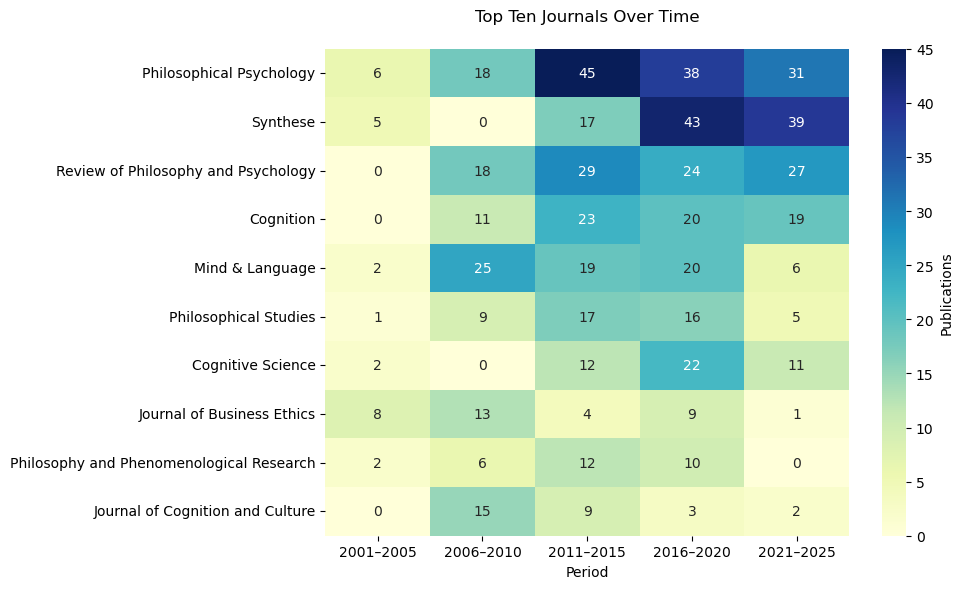

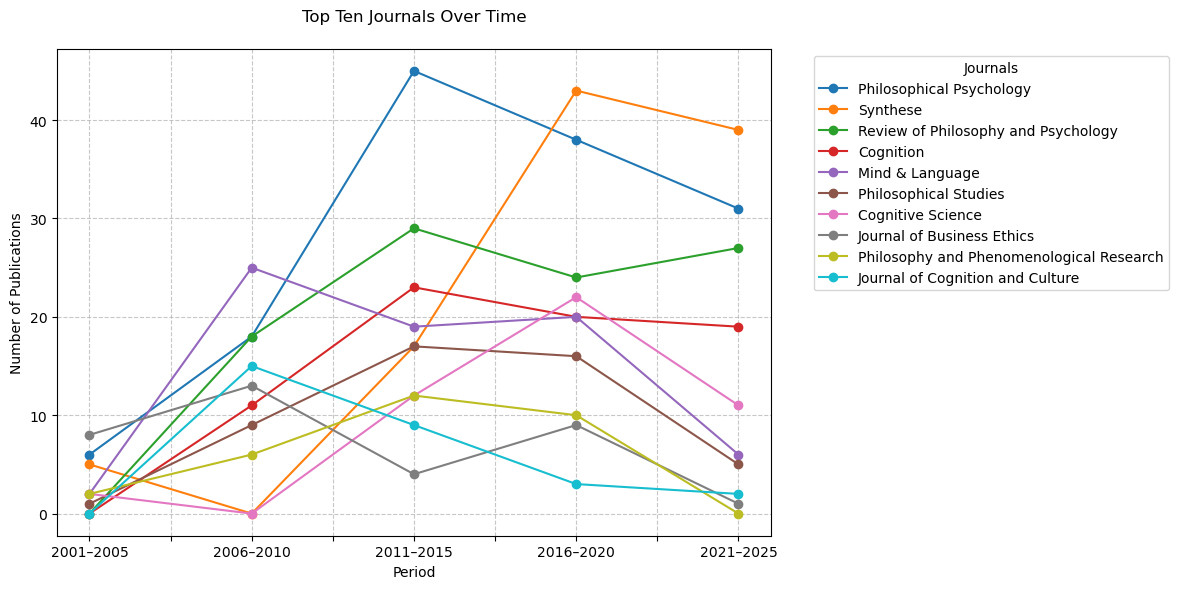

In [4]:
# Define visualization function
def visualize_trends(df_rank):
    
    # Check if DataFrame is missing or empty
    if df_rank is None or df_rank.empty:
        return
    
    # Isolate top ten and prepare data
    top10 = df_rank.head(10).set_index("Standardized source")[PERIODS]
    
    # Generate heatmap
    plt.figure(figsize = (10, 6))
    sns.heatmap(top10, annot = True, cmap = "YlGnBu", fmt = "g", cbar_kws = {'label': 'Publications'})
    plt.title("Top Ten Journals Over Time", pad = 20)
    plt.ylabel("Number of Publications")
    plt.ylabel("")
    
    # Export heatmap
    plt.tight_layout()
    plt.savefig("x_phi_journals_heatmap.pdf", bbox_inches = "tight")
    plt.show()
    
    # Generate line chart
    plt.figure(figsize = (12, 6))
    top10.T.plot(kind = "line", marker = "o", ax = plt.gca())
    plt.title("Top Ten Journals Over Time", pad = 20)
    plt.ylabel("Number of Publications")
    plt.grid(True, linestyle = "--", alpha = 0.7)
    plt.legend(title = "Journals", bbox_to_anchor = (1.05, 1), loc = 'upper left')
    
    # Export line chart
    plt.tight_layout()
    plt.savefig("x_phi_journals_line_chart.pdf", bbox_inches = "tight")
    plt.show()

# Run visualization function
visualize_trends(rank_table)